# Paddenstoelen classificeren op AWS SageMaker

Auteurs: vul hier jullie namen in.

Doel: een Random Forest trainen en tunen om eetbare paddenstoelen
te onderscheiden van giftige paddenstoelen of paddenstoelen met
onbekende eetbaarheid.

We gebruiken cross-validatie voor tuning en een aparte testset
voor de eindbeoordeling.

In [1]:
%pip install pandas scikit-learn ucimlrepo joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import pandas as pd
import sklearn

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.10.20 | packaged by conda-forge | (main, Jun 11 2026, 03:31:56) [GCC 14.3.0]
pandas: 2.3.3
scikit-learn: 1.7.2


In [3]:
import io
import urllib.request
import zipfile
from pathlib import Path
import pandas as pd

url = (
    "https://archive.ics.uci.edu/static/public/848/"
    "secondary+mushroom+dataset.zip"
)

# Download en bewaar het originele archief.
with urllib.request.urlopen(url, timeout=60) as response:
    zip_bytes = response.read()

Path("secondary_mushroom_dataset.zip").write_bytes(zip_bytes)

# Het downloadarchief bevat nog een tweede ZIP.
with zipfile.ZipFile(io.BytesIO(zip_bytes)) as outer:
    inner_bytes = outer.read("MushroomDataset.zip")

with zipfile.ZipFile(io.BytesIO(inner_bytes)) as inner:
    csv_bytes = inner.read("MushroomDataset/secondary_data.csv")

Path("secondary_data.csv").write_bytes(csv_bytes)

# Deze CSV gebruikt puntkomma's als scheidingsteken.
data = pd.read_csv(
    "secondary_data.csv",
    sep=";",
    na_values=["?"],
)

print("Rijen vóór verwijderen duplicaten:", len(data))
data = data.drop_duplicates().reset_index(drop=True)

labels = data.pop("class")
assert labels.isin(["e", "p"]).all()

X = data
y = labels.map({"e": 0, "p": 1}).rename("target")

print("Aantal rijen en kenmerken:", X.shape)
print("\nKlasseverdeling (0 = eetbaar, 1 = giftig/onbekend):")
print(y.value_counts())
display(X.head())

Rijen vóór verwijderen duplicaten: 61069
Aantal rijen en kenmerken: (60923, 20)

Klasseverdeling (0 = eetbaar, 1 = giftig/onbekend):
target
1    33742
0    27181
Name: count, dtype: int64


,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Trainingsrijen:", len(X_train))
print("Testrijen:", len(X_test))

Trainingsrijen: 48738
Testrijen: 12185


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_columns = X_train.select_dtypes(include="number").columns
categorical_columns = X_train.select_dtypes(exclude="number").columns

categorical_pipeline = Pipeline([
    ("fill", SimpleImputer(
        strategy="constant",
        fill_value="missing",
    )),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocessing = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=2,
    )),
])

print("Pipeline aangemaakt.")

Pipeline aangemaakt.


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

baseline_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring="f1",
    cv=cv,
    n_jobs=1,
)

print("F1 per fold:", baseline_scores)
print("Gemiddelde baseline F1:", baseline_scores.mean())

F1 per fold: [1. 1. 1.]
Gemiddelde baseline F1: 1.0


In [7]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions={
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_leaf": [1, 2],
    },
    n_iter=4,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=True,
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBaseline gemiddelde CV-F1:", baseline_scores.mean())
print("Beste gemiddelde CV-F1:", search.best_score_)
print("Beste instellingen:", search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END model__max_depth=24, model__min_samples_leaf=2, model__n_estimators=100; total time=   5.5s
[CV] END model__max_depth=24, model__min_samples_leaf=2, model__n_estimators=100; total time=   5.5s
[CV] END model__max_depth=24, model__min_samples_leaf=2, model__n_estimators=100; total time=   5.4s
[CV] END model__max_depth=24, model__min_samples_leaf=1, model__n_estimators=200; total time=  10.7s
[CV] END model__max_depth=24, model__min_samples_leaf=1, model__n_estimators=200; total time=  10.7s
[CV] END model__max_depth=24, model__min_samples_leaf=1, model__n_estimators=200; total time=  10.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=100; total time=   5.9s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=100; total time=   5.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=100; total time=   5.8s
[CV] END model__max_depth

Note: you may need to restart the kernel to use updated packages.


,accuracy,precision,recall,f1,roc_auc
0,1.0,1.0,1.0,1.0,1.0


                 precision    recall  f1-score   support

        eetbaar       1.00      1.00      1.00      5436
giftig/onbekend       1.00      1.00      1.00      6749

       accuracy                           1.00     12185
      macro avg       1.00      1.00      1.00     12185
   weighted avg       1.00      1.00      1.00     12185

Giftig/onbekend voorspeld als eetbaar: 0
Eetbaar voorspeld als giftig/onbekend: 0


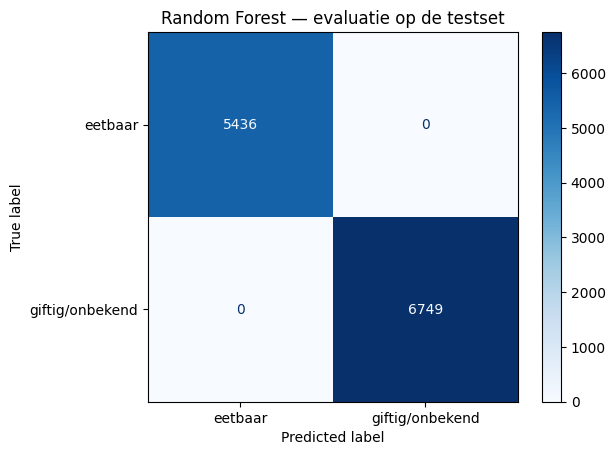

In [8]:
%pip install matplotlib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Voorspellen op de testset die niet voor tuning werd gebruikt.
predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, predictions),
    "precision": precision_score(y_test, predictions, zero_division=0),
    "recall": recall_score(y_test, predictions, zero_division=0),
    "f1": f1_score(y_test, predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_test, probabilities),
}

display(pd.DataFrame([test_metrics]).round(4))

print(classification_report(
    y_test,
    predictions,
    labels=[0, 1],
    target_names=["eetbaar", "giftig/onbekend"],
    zero_division=0,
))

cm = confusion_matrix(y_test, predictions, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("Giftig/onbekend voorspeld als eetbaar:", fn)
print("Eetbaar voorspeld als giftig/onbekend:", fp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["eetbaar", "giftig/onbekend"],
).plot(cmap="Blues")

plt.title("Random Forest — evaluatie op de testset")
plt.show()

In [9]:
import json
import joblib

# Bewaar preprocessing én model samen.
joblib.dump(best_model, "mushroom_pipeline.joblib")

# Bewaar alle tuningresultaten.
pd.DataFrame(search.cv_results_).to_csv(
    "aws_tuning_results.csv",
    index=False,
)

# Bewaar de eindresultaten en instellingen.
results = {
    "baseline_cv_f1": float(baseline_scores.mean()),
    "tuned_cv_f1": float(search.best_score_),
    "best_parameters": search.best_params_,
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "test_confusion_matrix": cm.tolist(),
}

with open("aws_results.json", "w", encoding="utf-8") as file:
    json.dump(results, file, indent=2)

print("Pipeline, tuningresultaten en eindbeoordeling opgeslagen.")

Pipeline, tuningresultaten en eindbeoordeling opgeslagen.


## Conclusie

- Basismodel: gemiddelde cross-validatie-F1 = …
- Beste getunede model: gemiddelde cross-validatie-F1 = …
- Gekozen hyperparameters: …
- F1 op de aparte testset = …
- ROC-AUC op de aparte testset = …
- Giftige/onbekende gevallen onterecht als eetbaar voorspeld = …

De tuning verbeterde / verbeterde niet de cross-validatiescore.
De testset werd uitsluitend gebruikt voor de eindbeoordeling.

De dataset bevat gesimuleerde paddenstoelen. Deze resultaten
bewijzen geen betrouwbaarheid voor het beoordelen van echte
paddenstoelen.